In [8]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random

In [4]:
class value:

    def __init__(self , data , _childern = () , _op = '' , label=''):
        self.data = data
        self.grad = 0.0
        self._bacward = lambda: None
        self._prev = set(_childern)
        self.label = label
        self._op = _op
        
    def __repr__(self): # to return a string we can see in a better way
        return f"Value(data = {self.data})"

    def __add__(self , other): # other -> b
        other = other if isinstance(other,value) else value(other)
        out = value(self.data + other.data , (self , other) , "+")
        def _bacward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._bacward = _bacward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = value(self.data ** other, (self,), f'**{other}')

        def _bacward():
            self.grad += (other * (self.data ** (other - 1))) * out.grad
        out._bacward = _bacward
        return out

    def exp(self):
        x = self.data
        out = value(math.exp(x), (self,), 'exp')
        def _bacward():
            self.grad += out.data * out.grad
        out._bacward = _bacward
        return out
        
    def __rmul__(self,other): # self * other
        return self * other

    def __radd__(self, other):
        return self + other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __neg__(self): # -self
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)
    
    def __mul__(self , other):
        other = other if isinstance(other,value) else value(other)
        new = value(self.data * other.data , (self , other) , "*")
        def _bacward():
            self.grad += other.data * new.grad
            other.grad += self.data * new.grad
        new._bacward = _bacward
        return new 

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = value(t, (self, ), 'tanh')
        def _bacward():
            self.grad += (1 - t**2) * out.grad 
        out._bacward = _bacward
        return out

    def backward(self):
        self.grad = 1.0
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
            topo.append(v)
        build_topo(self)
        for node in reversed(topo):
            node._bacward()


In [7]:
a = value(2.0)
b = value(4.0)
# 2 / 4 => 2 * (1/4) => 2 * (4**-1)-> this was our division function
a - b

Value(data = -2.0)

In [3]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s  | data %.4f | grad %.4f }" % (n.label , n.data , n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

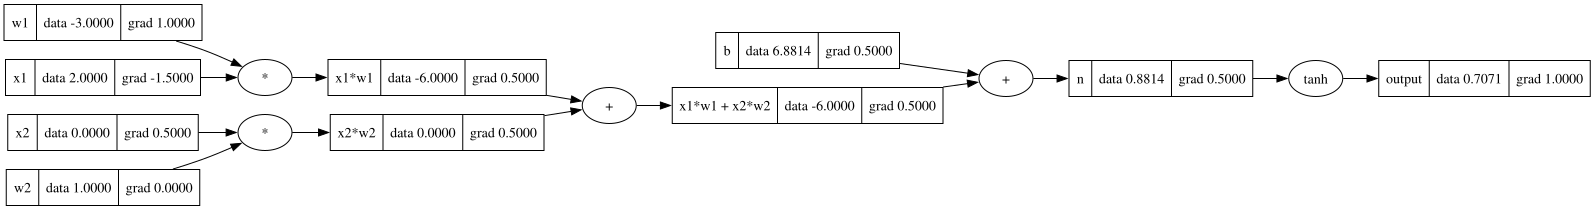

In [13]:
# inputs x1,x2
x1 = value(2.0, label='x1')
x2 = value(0.0, label='x2')

# weights w1,w2
w1 = value(-3.0, label='w1')
w2 = value(1.0, label='w2')

# bias of the neuron
b = value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label = 'n'
output = n.tanh();output.label = 'output'

output.backward()

draw_dot(output)

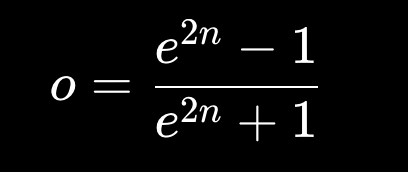

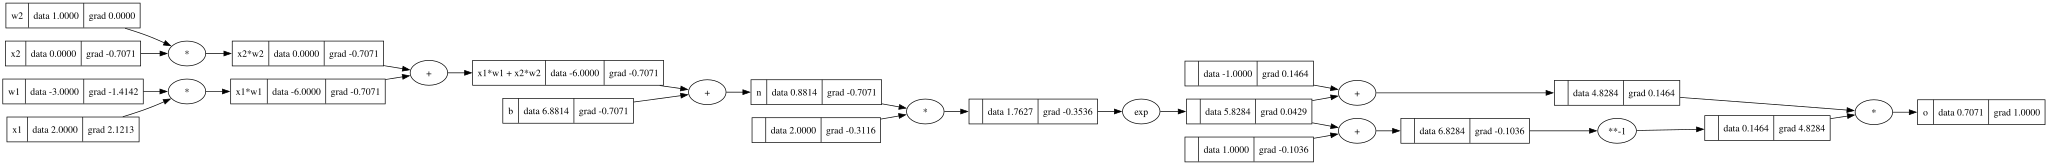

In [ ]:
# We will made our own tanh function 
# inputs x1,x2
x1 = value(2.0, label='x1')
x2 = value(0.0, label='x2')

# weights w1,w2
w1 = value(-3.0, label='w1')
w2 = value(1.0, label='w2')

# bias of the neuron
b = value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label = 'n'

# ----
e = (2*n).exp() # -> e^2*n
o = (e - 1) / (e + 1)
# ----

o.label = 'o'
o.backward()
draw_dot(o)

Now we are going to do ezactly same thing using pytorch library !

In [ ]:
# apni banyi hui vlaue class ki jarurat nahi hai !
import torch

x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


Building a neural net library:-

In [11]:
class Neuron:
  
  def __init__(self, nin):
    self.w = [value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = value(random.uniform(-1,1))
  
  def __call__(self, x): # When I try to run this object as fuction then call it ⬆️.
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b) # Har input ko uske weight se multiply karo, sabko add karo, aur bias laga do
    out = act.tanh() # -> Ye control kar raha hai raw output ko 
    return out

  def parameters(self):
     return self.w + [self.b] # extract the weigths and bias

class layer:
    def __init__(self , nin , non):
        self.neurons = [Neuron(nin) for _ in range(non)]

    def __call__(self , x):
       outs = [n(x) for n in self.neurons]
       return outs[0] if len(outs) == 1 else outs

    def parameters(self):
      return [p for neuron in self.neurons for p in neuron.parameters()]

# Multi-layer-Perseptron (MLP):
class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
     return [p for layer in self.layers for p in layer.parameters()]


In [41]:
x = [2.0 , 3.0 , -1.0]
# In n variable (2,3) are 2 -> dimentional neruon and 3 are total number of neurons
n = MLP(3 ,[4,4,1])
n(x)

Value(data = 0.057118154700355445)

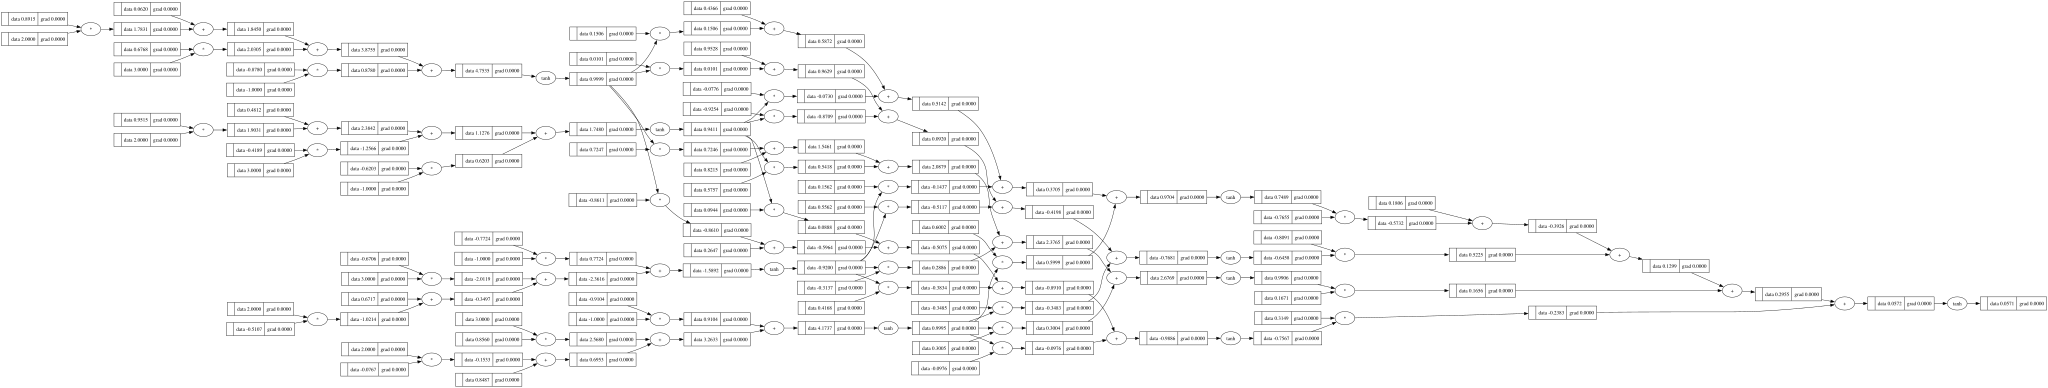

In [42]:
draw_dot(n(x))

In [43]:
# exmaples:-
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
y_pred = [n(x) for x in xs]
y_pred

[Value(data = 0.057118154700355445),
 Value(data = 0.1623759477178254),
 Value(data = -0.5117919245117439),
 Value(data = -0.33234889912936727)]

In [ ]:
# Mean squared error:-
loss = sum([(yout - ygt)**2 for ygt , yout in zip(ys , y_pred)])
loss # -> 5.401635354779982 , we wanted to minimise the loss

Value(data = 4.253644732011759)

In [46]:
n.layers[0].neurons[0].w[0].grad

0.0

In [50]:
n.layers[0].neurons[0].w[0].data

0.8915356393600806

In [56]:
# this MLP has 41 parameters:-
len(n.parameters())

41

In [57]:
for p in n.parameters():
    p.data += -0.01 * p.grad 

In [58]:
n.layers[0].neurons[0].w[0].data

0.8915356393600806

In [59]:
y_pred = [n(x) for x in xs]
loss = sum([(yout - ygt)**2 for ygt , yout in zip(ys , y_pred)])
loss 

Value(data = 4.253644732011759)

In [6]:
import random

In [ ]:
class Neuron:
  
  def __init__(self, nin):
    self.w = [value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

class layer:
    def __init__(self , nin , non):
        self.neurons = [Neuron(nin) for _ in range(non)]

    def __call__(self , x):
       outs = [n(x) for n in self.neurons]
       return outs

class MLP:
    def __init__(self, no_input , no_neuron):
        size = [no_input] + no_neuron
        self.layers = [layer(size[i] , size[i+1]) for i in range(len(no_neuron))]

    def __call__(self ,x):
        for l in self.layers:
            x = l(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

[Value(data = 0.6829481683900546),
 Value(data = -0.9962591921693086),
 Value(data = 0.9145878489310847)]